# 02 — Preprocessing

**Input:** `data/raw/raw_data.csv`  
**Output:** `data/processed/processed_data.csv`

Steps:
1. Drop `ID`
2. Impute missing values
3. Outlier detection & removal (IQR method)
4. Encode categoricals
5. Feature scaling (StandardScaler)


In [1]:
import sys
print(sys.executable)

c:\customer-segmentation-purchace-Behaviour-Classification\.venv\Scripts\python.exe


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/raw_data.csv')
print('Raw shape:', df.shape)
df.head()

Raw shape: (8068, 10)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6


## Step 1 — Drop Unused Columns

In [3]:
df = df.drop(columns=['ID'], errors='ignore')
print('After drop:', df.shape)

After drop: (8068, 9)


## Step 2 — Impute Missing Values

In [4]:
print('Missing before imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Numeric: fill with median
num_cols = df.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical: fill with mode
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('\nMissing after imputation:', df.isnull().sum().sum())

Missing before imputation:
Ever_Married       140
Graduated           78
Profession         124
Work_Experience    829
Family_Size        335
Var_1               76
dtype: int64

Missing after imputation: 1582


## Step 3 — Outlier Detection & Removal (IQR)

Visualise boxplots before removal, then apply IQR-based capping.

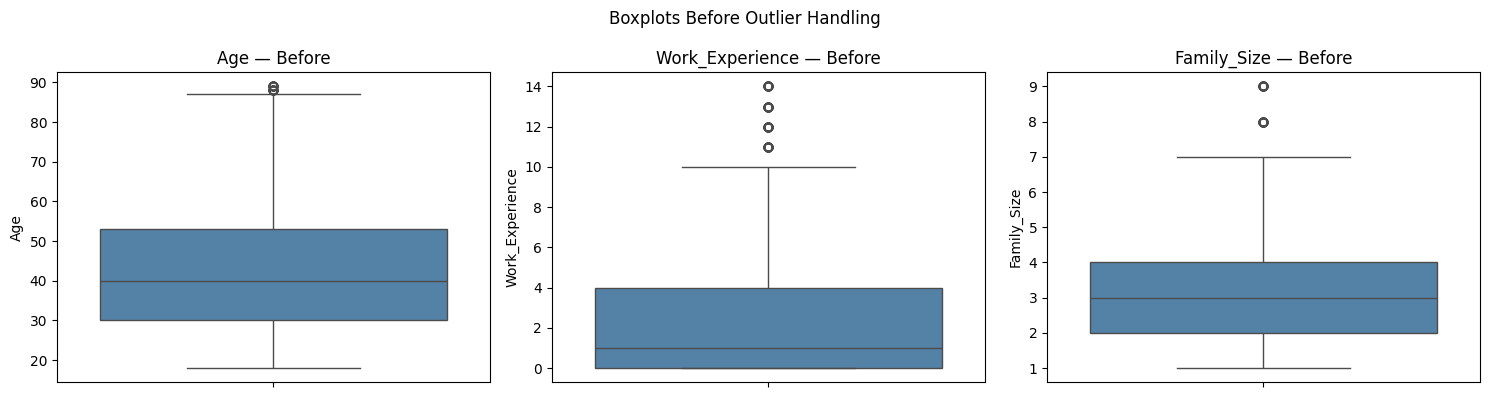

In [5]:
# --- Boxplots BEFORE handling ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Work_Experience', 'Family_Size']):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(f'{col} — Before')
plt.suptitle('Boxplots Before Outlier Handling')
plt.tight_layout()
plt.show()

In [ ]:
# IQR Capping (Winsorization) — cap outliers at 1.5*IQR fences
outlier_cols = ['Age', 'Work_Experience', 'Family_Size']

for col in outlier_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = df[col].shape[0]
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    # Cap (winsorise) instead of drop — preserves row count
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f'{col}: {outliers} outliers capped  (lower={lower:.1f}, upper={upper:.1f})')

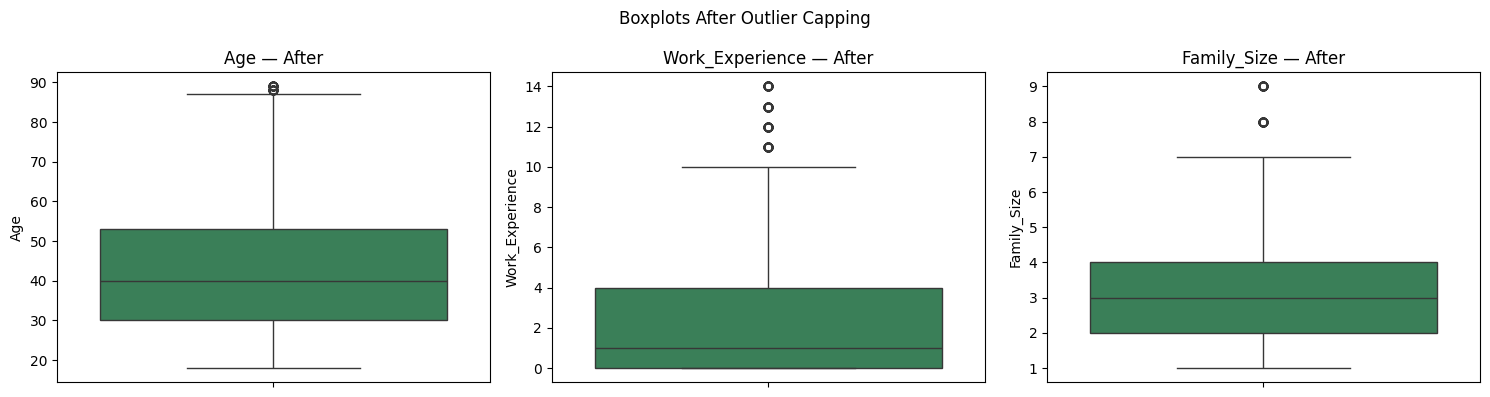

In [6]:
# --- Boxplots AFTER handling ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Work_Experience', 'Family_Size']):
    sns.boxplot(y=df[col], ax=ax, color='seagreen')
    ax.set_title(f'{col} — After')
plt.suptitle('Boxplots After Outlier Capping')
plt.tight_layout()
plt.show()

## Step 4 — Encode Categoricals

In [10]:
le = LabelEncoder()

# Ordinal encoding for Spending_Score
spending_map = {'Low': 0, 'Average': 1, 'High': 2}
df['Spending_Score'] = df['Spending_Score'].map(spending_map)

# Binary encoding
binary_map = {'Male': 1, 'Female': 0, 'Yes': 1, 'No': 0}
for col in ['Gender', 'Ever_Married', 'Graduated']:
    df[col] = df[col].map(binary_map)

# Label encode remaining objects (Profession, Var_1)
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

print('Dtypes after encoding:')
print(df.dtypes)
df.head()

Dtypes after encoding:
Gender               int64
Ever_Married       float64
Age                  int64
Graduated          float64
Profession           int64
Work_Experience    float64
Spending_Score       int64
Family_Size        float64
Var_1                int64
dtype: object


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,1,0.0,22,0.0,5,1.0,0,4.0,3
1,0,1.0,38,1.0,2,NaN,1,3.0,3
2,0,1.0,67,1.0,2,1.0,0,1.0,5
3,1,1.0,67,1.0,7,0.0,2,2.0,5
4,0,1.0,40,1.0,3,NaN,2,6.0,5


## Step 5 — Feature Scaling (StandardScaler)

In [11]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print('Scaled stats (mean ≈ 0, std ≈ 1):')
df_scaled.describe().round(2)

Scaled stats (mean ≈ 0, std ≈ 1):


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
count,8068.00,7928.00,8068.00,7990.00,8068.00,7239.00,8068.00,7733.00,8068.00
mean,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.10,-1.19,-1.52,-1.28,-1.10,-0.78,-0.74,-1.21,-2.89
25%,-1.10,-1.19,-0.81,-1.28,-1.10,-0.78,-0.74,-0.56,-0.81
50%,0.91,0.84,-0.21,0.78,0.04,-0.48,-0.74,0.10,0.58
75%,0.91,0.84,0.57,0.78,0.80,0.40,0.61,0.75,0.58
max,0.91,0.84,2.72,0.78,2.32,3.33,1.96,4.02,1.96


## Correlation Heatmap (after processing)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

## Save Processed Data

In [16]:


import os

# create folder if not exists
os.makedirs('../data/processed', exist_ok=True)

# save file
df_scaled.to_csv('../data/processed/processed_data.csv', index=False)

print('Saved processed_data.csv — shape:', df_scaled.shape)

Saved processed_data.csv — shape: (8068, 9)
